# Step 8.1: What drives the model overall (SHAP)

For every single prediction, SHAP measures how much each feature **pushed the score up or down**.
Starting point (base value) + all the pushes = the model's score, exactly. It's like an itemised receipt.

**Overall importance** = the average size of each feature's push across many transactions. It's fairer than gain, because it's measured on actual predictions, not on how the trees were built.

Champion XGBoost, on **val**. Test stays closed.

In [1]:
import numpy as np
import pandas as pd
import shap
from xgboost import XGBClassifier

c:\Users\srisu\OneDrive\Desktop\MachineLearning\Production Grade Projects\Fraud Detection\ml environment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
val = pd.read_parquet("../data/processed/val.parquet")

features = [
    "amt", "category", "hour", "age",
    "secs_since_last", "is_first_txn",
    "card_avg_amt_before", "amt_ratio", "txn_count_24h",
]
target = "is_fraud"

X_train, y_train = train[features], train[target]
X_val, y_val = val[features], val[target]

In [3]:
# Rebuild the champion: exactly the Step 6.3 settings (the model isn't saved to a file yet)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_es = XGBClassifier(
    tree_method="hist",
    enable_categorical=True,
    scale_pos_weight=scale_pos_weight,
    n_estimators=2000,
    early_stopping_rounds=50,
    eval_metric="aucpr",
)
xgb_es.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print("Trees kept:", xgb_es.best_iteration + 1)   # should be 86, same as Step 6.3

Trees kept: 86


In [4]:
# Sample: ALL val frauds + 5,000 random normal transactions.
# A purely random sample would have only about 33 frauds (0.56%), too few to explain fraud.
val_frauds = X_val[y_val == 1]
val_normals = X_val[y_val == 0].sample(5000, random_state=42)   # fixed seed = same sample every run

sample = pd.concat([val_frauds, val_normals])
print("Sample:", len(sample), "rows =", len(val_frauds), "frauds +", len(val_normals), "normal")

Sample: 6256 rows = 1256 frauds + 5000 normal


In [5]:
explainer = shap.TreeExplainer(xgb_es)
shap_values = explainer.shap_values(sample)   # one row per transaction, one column per feature

print("SHAP grid shape:", shap_values.shape)
print("Base value (starting point, in log-odds):", round(float(explainer.expected_value), 3))

SHAP grid shape: (6256, 9)
Base value (starting point, in log-odds): -0.023


In [6]:
# Receipt check for one transaction: base value + all pushes = the model's raw score (log-odds)
row = 0
receipt_total = explainer.expected_value + shap_values[row].sum()
model_raw_score = xgb_es.predict(sample.iloc[[row]], output_margin=True)[0]

print("Base + pushes:", round(float(receipt_total), 4))
print("Model raw score:", round(float(model_raw_score), 4))
print("Pushes for this transaction:")
print(pd.Series(shap_values[row], index=features).round(3).sort_values())

Base + pushes: 6.0297
Model raw score: 6.0297
Pushes for this transaction:
card_avg_amt_before   -0.654
is_first_txn           0.000
secs_since_last        0.027
amt_ratio              0.159
txn_count_24h          0.260
age                    0.416
hour                   0.954
amt                    1.519
category               3.372
dtype: float32


In [7]:
# Overall importance: average SIZE of each feature's push (ignore up or down)
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=features).sort_values(ascending=False)
shap_importance.round(3)

amt                    4.440
category               3.263
hour                   1.410
age                    0.691
secs_since_last        0.670
card_avg_amt_before    0.530
txn_count_24h          0.448
amt_ratio              0.385
is_first_txn           0.000
dtype: float32

In [8]:
# Compare with the gain top 5 from Step 6.2
gain_top5 = ["amt", "category", "hour", "card_avg_amt_before", "txn_count_24h"]

comparison = pd.DataFrame({
    "Gain (6.2)": gain_top5,
    "SHAP (8.1)": shap_importance.index[:5],
    "Mean |SHAP|": shap_importance.values[:5].round(3),
}, index=range(1, 6))
comparison

,Gain (6.2),SHAP (8.1),Mean |SHAP|
1,amt,amt,4.440
2,category,category,3.263
3,hour,hour,1.410
4,card_avg_amt_before,age,0.691
5,txn_count_24h,secs_since_last,0.670


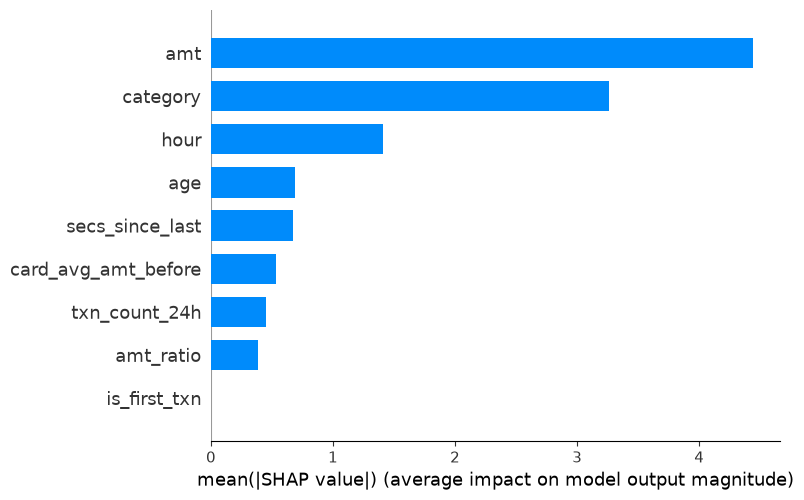

In [9]:
# Picture of the same ranking (bar = average size of the push)
shap.summary_plot(shap_values, sample, plot_type="bar")

## Step 8.2: Explaining single transactions (reason codes)

"The model said 0.97" helps nobody. "Amount is 6× this card's usual, at 2am, in online shopping" helps both the **fraud analyst** and the **customer**. These short reasons are **reason codes**.

Champion XGBoost, val, cutoff 0.90. Two transactions:
- the **highest-scoring real fraud**
- the **highest-scoring false alarm** (a normal transaction scored ≥ 0.90)

In [11]:
# Fraud scores for all of val, kept with their row labels
val_scores = pd.Series(xgb_es.predict_proba(X_val)[:, 1], index=X_val.index)

# 1. Highest-scoring REAL fraud
top_fraud_id = val_scores[y_val == 1].idxmax()

# 2. Highest-scoring FALSE ALARM: a normal transaction scored at or above the 0.90 cutoff
false_alarms = val_scores[(y_val == 0) & (val_scores >= 0.90)]
top_false_alarm_id = false_alarms.idxmax()

print(f"Real fraud:  row {top_fraud_id}, score {val_scores[top_fraud_id]:.4f}")
print(f"False alarm: row {top_false_alarm_id}, score {val_scores[top_false_alarm_id]:.4f}")
print(f"False alarms at >= 0.90 in val: {len(false_alarms)}")   # should be 312, same as Step 7

Real fraud:  row 1754, score 1.0000
False alarm: row 132106, score 0.9995
False alarms at >= 0.90 in val: 312


In [12]:
# Top features by SHAP push for ONE transaction: its actual value, the push, and the direction
def reason_table(row_id, top_n=3):
    row = X_val.loc[[row_id]]                 # double brackets = keep it a one-row table
    pushes = explainer.shap_values(row)[0]    # 9 pushes, one per feature

    table = pd.DataFrame({
        "feature": features,
        "value": row.iloc[0].values,
        "push": pushes.round(3),
    })
    table["direction"] = np.where(table["push"] > 0, "up", "down")

    # Biggest push first, ignoring up or down
    table = table.reindex(table["push"].abs().sort_values(ascending=False).index)
    return table.head(top_n).reset_index(drop=True)

In [13]:
# Turn a feature and its value into words a fraud analyst or customer understands
def plain_english(feature, value):
    if pd.isna(value):
        return "No earlier purchase on record for this card"
    if feature == "amt":
        return f"Amount ${value:,.2f}"
    if feature == "category":
        return f"Category: {value}"
    if feature == "hour":
        return f"At {int(value):02d}:00"
    if feature == "age":
        return f"Cardholder aged {int(value)}"
    if feature == "amt_ratio":
        return f"{value:.1f}x this card's usual spend"
    if feature == "card_avg_amt_before":
        return f"This card usually spends ${value:,.2f}"
    if feature == "secs_since_last":
        return f"{value / 3600:.1f} h since the card's last purchase"
    if feature == "txn_count_24h":
        return f"{int(value)} purchases on this card in the last 24 h"
    if feature == "is_first_txn":
        return "First purchase seen on this card" if value == 1 else "Card has earlier purchases"
    return f"{feature} = {value}"

In [14]:
for name, row_id in [("REAL FRAUD", top_fraud_id), ("FALSE ALARM", top_false_alarm_id)]:
    table = reason_table(row_id)
    table["reason code"] = [
        f"{plain_english(f, v)} (pushed {d})"
        for f, v, d in zip(table["feature"], table["value"], table["direction"])
    ]
    print(f"\n{name}: score {val_scores[row_id]:.4f}")
    print(table.to_string())


REAL FRAUD: score 1.0000
           feature    value   push direction                                        reason code
0              amt   702.24  8.127        up                         Amount $702.24 (pushed up)
1             hour       23  3.145        up                               At 23:00 (pushed up)
2  secs_since_last  74733.0  1.884        up  20.8 h since the card's last purchase (pushed up)

FALSE ALARM: score 0.9995
    feature        value   push direction                        reason code
0       amt       269.18  5.635        up         Amount $269.18 (pushed up)
1  category  grocery_pos  2.030        up  Category: grocery_pos (pushed up)
2      hour            3  1.033        up               At 03:00 (pushed up)


In [15]:
# All 9 values side by side: helps see why the false alarm looked like fraud
pd.DataFrame({
    "Real fraud": X_val.loc[top_fraud_id],
    "False alarm": X_val.loc[top_false_alarm_id],
})

,Real fraud,False alarm
amt,702.24,269.18
category,misc_net,grocery_pos
hour,23,3
age,90,41
secs_since_last,74733.0,1877.0
is_first_txn,0,0
card_avg_amt_before,60.526815,92.776769
amt_ratio,11.60213,2.901373
txn_count_24h,6.0,8.0


## Step 8.3: Fairness check (gender and age)

"Fair" doesn't mean every group gets flagged equally often: a group with more fraud should get more alerts. Instead we compare two things that **should be similar for every group**:
- **False alarm rate** = false alarms ÷ normal transactions in the group. The main harm: real people having their cards blocked.
- **Recall** = frauds caught ÷ frauds in the group. Every group deserves equal protection.

Done on **val**, not test: if this leads to dropping `age`, that changes the model, and decisions must never be based on test. Cutoff 0.90.

In [16]:
def fairness_table(group_column, cutoff=0.90):
    data = pd.DataFrame({
        "group": group_column,
        "fraud": y_val,
        "flagged": val_scores >= cutoff,
    })

    def one_row(g):
        normal = g[g["fraud"] == 0]
        fraud = g[g["fraud"] == 1]
        return {
            "transactions": len(g),
            "frauds": len(fraud),                                            # small = recall is noisy
            "fraud rate %": round(g["fraud"].mean() * 100, 3),
            "false alarm rate %": round(normal["flagged"].mean() * 100, 3),  # innocent people wrongly flagged
            "recall %": round(fraud["flagged"].mean() * 100, 1),             # frauds caught
        }

    rows = {group: one_row(g) for group, g in data.groupby("group", observed=True)}
    rows["All"] = one_row(data)   # reference line to compare each group against
    return pd.DataFrame(rows).T

In [17]:
# By gender (a helper column: kept in the file for exactly this check, never given to the model)
fairness_table(val["gender"])

,transactions,frauds,fraud rate %,false alarm rate %,recall %
F,123560.0,642.0,0.520,0.164,86.9
M,102149.0,614.0,0.601,0.108,94.0
All,225709.0,1256.0,0.556,0.139,90.4


In [18]:
# By age group (the same buckets as Step 2)
bins = [0, 25, 35, 45, 55, 65, 75, np.inf]
labels = ["Under 25", "25-35", "35-45", "45-55", "55-65", "65-75", "75+"]
age_group = pd.cut(X_val["age"], bins=bins, labels=labels, right=False)

fairness_table(age_group)

,transactions,frauds,fraud rate %,false alarm rate %,recall %
Under 25,20588.0,71.0,0.345,0.088,90.1
25-35,47155.0,256.0,0.543,0.196,85.2
35-45,48732.0,167.0,0.343,0.196,80.8
45-55,45629.0,265.0,0.581,0.139,89.1
55-65,28077.0,195.0,0.695,0.075,97.9
65-75,18786.0,124.0,0.660,0.070,98.4
75+,16742.0,178.0,1.063,0.060,94.9
All,225709.0,1256.0,0.556,0.139,90.4


# Decisions summary (the source for `params.yaml` and the pipeline checklist)

## Data and split
| Decision | Value |
|---|---|
| Raw data | `data/raw/fraudTrain.csv` (Jan 2019 – 21 Jun 2020), `fraudTest.csv` (21 Jun – 31 Dec 2020) |
| Validation cut date | **2020-03-21 00:00** (train = before, val = on or after) |
| Test | Kept separate; opened **once** (Step 7.3) |
| Rows | train 1,070,966 · val 225,709 · test 555,719 |
| Fraud rate | train 0.584% · val 0.556% · test 0.386% |
| Files | `data/interim/features_{train,test}.parquet` → `data/processed/{train,val,test}.parquet` |

## Features (9)
| Feature | How it's built |
|---|---|
| `amt` | Raw amount |
| `category` | 14 values, pandas `category` type (same 14 categories in every set) |
| `hour` | Hour of `trans_date_trans_time` |
| `age` | (transaction time − `dob`) in days ÷ 365.25, rounded down |
| `secs_since_last` | Seconds since the card's previous transaction (empty for a card's first) |
| `is_first_txn` | 1 if `secs_since_last` is empty. **Drop for trees:** SHAP = 0.00, because XGBoost reads the empty value directly |
| `card_avg_amt_before` | Average `amt` of the card's **previous** transactions only |
| `amt_ratio` | `amt` ÷ `card_avg_amt_before` |
| `txn_count_24h` | The card's transactions in the last 24 hours, including this one (time window) |

All card features are computed on train + test **combined**, sorted by `cc_num` then time, **per card**, using only the past.

## Target and helpers
- **Target:** `is_fraud`
- **Helpers (kept in the files, never given to the model):** `trans_date_trans_time` (split, sorting), `cc_num` (card history, tracing decisions), `gender` (fairness checks only; protected attribute)

## Dropped columns
| Column | Reason |
|---|---|
| `Unnamed: 0` | Old CSV row number; won't exist for a live transaction |
| `unix_time` | Same clock time with the year relabelled (−2556/−2557 days); adds nothing |
| `trans_num` | Random ID per transaction; only memorised |
| `first`, `last`, `street` | Personal identifiers; nametags |
| `merch_lat`, `merch_long`, `distance_km` | Merchant location is random per transaction; distance has no signal (76.3 vs 76.1 km) |
| `merchant` | Spread between merchants is no bigger than chance once category is known |
| `state` | Signal only from tiny states (DE = 1 card, 100% fraud) |
| `city`, `zip`, `job`, `lat`, `long`, `city_pop` | About 1–2 people per value, so they're nametags |
| `dob` | Turned into `age` |
| `gender` | Not a feature (protected attribute); kept as a helper for fairness |
| `dataset` | Internal train/test tag used only while building card features |

## Model (champion)
| Setting | Value |
|---|---|
| Algorithm | XGBoost `XGBClassifier` |
| `tree_method` | `"hist"` |
| `enable_categorical` | `True` |
| `scale_pos_weight` | **170.4** (normal ÷ fraud in train) |
| `n_estimators` | 2000 (ceiling) |
| `early_stopping_rounds` | **50**, watching val, `eval_metric="aucpr"` |
| Trees kept | **86** (best_iteration 85) |
| Everything else | XGBoost defaults |
| Preprocessing | None (no filling, log, scaling or one-hot) |

## Cutoff
| Decision | Value |
|---|---|
| Cutoff in use | **0.90**: fits the team's capacity of about 1,500 alerts per 3 months (val: 1,447 alerts, recall 90.4%, precision 78.4%) |
| If the team grows | **0.59**: the cheapest on val ($35,211 vs $44,406), but 2,144 alerts |
| Alert cost | **$10 per alert (an assumption)**; a missed fraud costs its `amt` |

## Notebook scores the pipeline must match (first automatic test)
| Set | PR-AUC | ROC-AUC |
|---|---|---|
| **Val** | **0.940** | 0.999 |
| **Test** | **0.906** | 0.998 |

The Python pipeline should land at about **0.940 on val**. If it does, the code matches the notebook. If not, there's a bug.

Baseline for reference: logistic regression val PR-AUC 0.221. LightGBM (lr 0.05) tied at 0.941 but was about 13× slower to score.

## Open experiments for later
1. **Retrain without `age`** (fairness): ages 25–45 get the highest false alarm rates (0.196%) and the lowest recall (81–85%). Check whether the gap closes and what it costs in PR-AUC, deciding on val.
2. **Gender gap through proxies:** women get 0.164% false alarms vs 0.108% for men, and 86.9% recall vs 94.0%. Investigate which features act as proxies.
3. **"Count compared to the card's usual"** feature: `txn_count_24h` relative to the card's normal daily count (the raw count was weak: 5.23 vs 4.88).
4. **Drop `is_first_txn`** for the tree model (SHAP = 0).